In [ ]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from multistyleseg.data.fundus.consts import Lesions, ALL_CLASSES
from multistyleseg.analysis.dr_grading.hmr_diagnosis import (
    create_diagnosis,
    get_macular_severity,
    standardize_macular_threat,
    get_retinopathy_severity,
    standardize_retinopathy,
)


In [2]:
root_gt = Path("/home/clement/Documents/data/IVisionHMR/metadata")
df_male = pd.read_csv(root_gt / "male.csv")
df_female = pd.read_csv(root_gt / "female.csv")
df_gt = pd.concat([df_male, df_female], ignore_index=True)
root_inference = Path("ensemble_inference")
all_pickles_files = list(root_inference.glob("*.pkl"))

root_macula = Path("od_mac")
all_pickles_files_macula = list(root_macula.glob("*.pkl"))
# Read and concatenate all pickle files
df_inference = pd.concat(
    [pd.read_pickle(pkl_file) for pkl_file in all_pickles_files], ignore_index=True
)
df_od_mac = pd.concat(
    [pd.read_pickle(pkl_file) for pkl_file in all_pickles_files_macula],
    ignore_index=True,
)
df_od_mac.od_valid = df_od_mac.od_valid.apply(lambda x: bool(x))
df_od_mac.macula_valid = df_od_mac.macula_valid.apply(lambda x: bool(x))

ValueError: No objects to concatenate

In [ ]:
COLS_DIAGNOSIS = [
    "Rétinopathie diabétique ",
    "Menace diabétique de la macula ",
    "DMLA ",
]


In [ ]:
# For image_id in df_inference, look at the corresponding diagnosis in df_gt
results = []
for image_id in df_inference["image_id"].unique():
    for laterality in ["OS", "OD"]:
        laterality_columns = [col + laterality for col in COLS_DIAGNOSIS]
        gt = df_gt[df_gt["No session"] == int(image_id)][laterality_columns]
        # We rename the columns to remove laterality
        gt = gt.rename(
            columns={
                col: col.replace(f" {laterality}", "") for col in laterality_columns
            }
        )
        pred = df_inference[
            (df_inference["image_id"] == image_id)
            & (df_inference["laterality"] == laterality)
        ]
        gt["session_id"] = image_id
        gt["laterality"] = laterality
        od_mac_row = df_od_mac[
            (df_od_mac["image_id"] == image_id)
            & (df_od_mac["laterality"] == laterality)
        ]
        for lesion in ALL_CLASSES:
            pred_lesion = pred[pred.lesion_id == lesion.name]
            gt["N " + lesion.name] = len(pred_lesion)
        for lesion in ALL_CLASSES:
            # For each lesion, we check if within 150 pixels of the macula center
            # If yes, we consider it as threatening the macula
            threatening_lesions = 0
            for _, row in pred[pred.lesion_id == lesion.name].iterrows():
                if od_mac_row.iloc[0].macula_valid == False:
                    threatening_lesions = np.nan
                    break

                macula_x, macula_y = tuple(od_mac_row.iloc[0]["macula"])
                lesion_y, lesion_x = row["centroid"]
                distance = np.sqrt(
                    (macula_x - lesion_x) ** 2 + (macula_y - lesion_y) ** 2
                )
                if distance <= 150 and od_mac_row.iloc[0]["macula_valid"]:
                    threatening_lesions += 1
            gt[f"N {lesion.name} threatening macula"] = threatening_lesions
        results.append(gt)
merged_results = pd.concat(results, ignore_index=True)
merged_results["N Exudates, Hemorrhages, Microaneurysms"] = merged_results[
    ["N " + lesion.name for lesion in [Lesions.HEMORRHAGES, Lesions.MICROANEURYSMS]]
].sum(axis=1)

In [ ]:
merged_results["N Significant"] = merged_results[
    "N Exudates, Hemorrhages, Microaneurysms"
]

In [ ]:
df = merged_results.copy()
# Standardize columns
df["Retinopathy_std"] = df["Rétinopathie diabétique"].apply(standardize_retinopathy)
df["Macular_std"] = df["Menace diabétique de la macula"].apply(
    standardize_macular_threat
)

# Add severity scores for sorting
df["Retino_severity"] = df["Retinopathy_std"].apply(get_retinopathy_severity)
df["Macular_severity"] = df["Macular_std"].apply(get_macular_severity)

# Create combined category (C3) and diagnosis
df["C3"] = df["Retinopathy_std"] + " | " + df["Macular_std"]
df["Diagnosis"] = df.apply(create_diagnosis, axis=1)


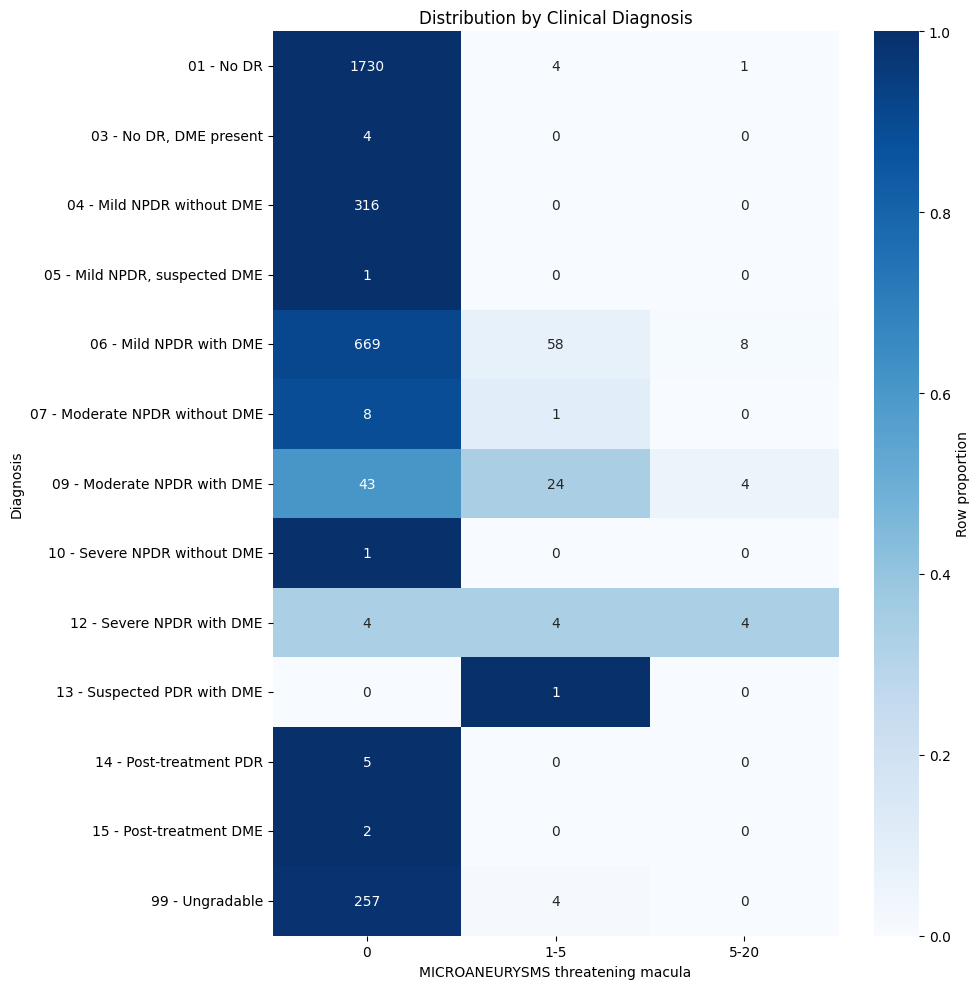

In [ ]:
# Bin the N Significant column
bins = [0, 2, 5, 20, np.inf]
labels = ["0", "1-5", "5-20", ">20"]
choice = "MICROANEURYSMS"  # Change this to choose different lesion type
choice = "Exudates, Hemorrhages, Microaneurysms"
choice = "MICROANEURYSMS threatening macula"
df["binned"] = pd.cut(df[f"N {choice}"], bins=bins, labels=labels, right=False)

# Option A: Using Diagnosis
confusion_diag = pd.crosstab(df["Diagnosis"], df["binned"])
confusion_diag = confusion_diag.sort_index()
confusion_diag_norm = confusion_diag.div(
    confusion_diag.sum(axis=1), axis=0
)  # Row-normalize

# Option B: Using C3
confusion_c3 = pd.crosstab(df["C3"], df["binned"])
c3_order = (
    df.drop_duplicates("C3")
    .sort_values(["Retino_severity", "Macular_severity"])["C3"]
    .tolist()
)
c3_order = [c for c in c3_order if c in confusion_c3.index]
confusion_c3 = confusion_c3.reindex(c3_order)
confusion_c3_norm = confusion_c3.div(confusion_c3.sum(axis=1), axis=0)  # Row-normalize


# =============================================================================
# 6. PLOT (with normalized colors but absolute counts as annotations)
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot Diagnosis - color by proportion, annotate with counts
sns.heatmap(
    confusion_diag_norm,
    annot=confusion_diag,
    fmt="d",
    cmap="Blues",
    ax=ax,
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Row proportion"},
)
ax.set_xlabel(f"{choice}")
ax.set_ylabel("Diagnosis")
ax.set_title("Distribution by Clinical Diagnosis")


plt.tight_layout()
plt.show()


=== ORDINAL AGREEMENT (Weighted Kappa) ===
Cohen Kappa (unweighted): 0.1896
Linear Weighted Kappa: 0.2849
Quadratic Weighted Kappa: 0.4262

=== REFERABLE DR DETECTION ===

Evaluating referable detection using N COTTON_WOOL_SPOT...

Threshold ≥1:
  Sensitivity: 0.1337
  Specificity: 0.9251
  PPV: 0.4259
  NPV: 0.7197
  Accuracy: 0.6926

Threshold ≥5:
  Sensitivity: 0.0167
  Specificity: 0.9955
  PPV: 0.6087
  NPV: 0.7088
  Accuracy: 0.7080

Threshold ≥10:
  Sensitivity: 0.0048
  Specificity: 0.9970
  PPV: 0.4000
  NPV: 0.7066
  Accuracy: 0.7056

Threshold ≥15:
  Sensitivity: 0.0024
  Specificity: 0.9985
  PPV: 0.4000
  NPV: 0.7065
  Accuracy: 0.7059

Threshold ≥20:
  Sensitivity: 0.0012
  Specificity: 0.9995
  PPV: 0.5000
  NPV: 0.7064
  Accuracy: 0.7063

N COTTON_WOOL_SPOT (AUC):
  AUC-ROC: 0.5304

All lesions (LR, 5-fold CV):
  AUC-ROC mean: 0.5306
  AUC-ROC std: 0.0167

Evaluating referable detection using N EXUDATES...

Threshold ≥1:
  Sensitivity: 0.5418
  Specificity: 0.5732
  PP

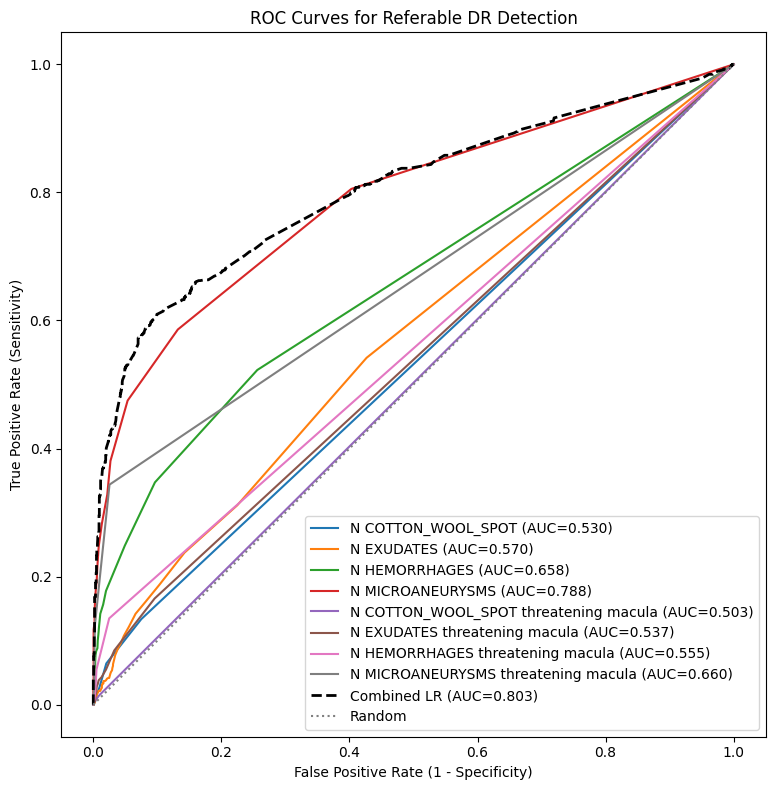

In [ ]:
from multistyleseg.analysis.dr_grading.eval import (
    evaluate_correlations,
    evaluate_ordinal_classification,
    evaluate_referable_detection,
    evaluate_mutual_information,
    evaluate_individual_lesions,
    create_summary_scorecard,
)
from multistyleseg.experiments.fundus.IVisionHMR.chart import plot_roc_curves


def get_diagnosis_severity(diag):
    """Extract numeric severity from diagnosis string."""
    if pd.isna(diag) or "Ungradable" in str(diag):
        return np.nan
    try:
        return int(str(diag).split(" - ")[0])
    except:
        return np.nan


df["Diagnosis_severity"] = df["Diagnosis"].apply(get_diagnosis_severity)


# Also create a simplified "referable DR" binary target
# Referable = Moderate NPDR or worse, OR any DME
def is_referable(diag):
    """Sight-threatening DR requiring referral."""
    if pd.isna(diag) or "Ungradable" in str(diag):
        return np.nan
    severity = get_diagnosis_severity(diag)
    if severity is None:
        return np.nan
    # Referable: diagnosis >= 7 (Moderate NPDR) or any DME (codes 3, 6, 9, 12, etc.)
    has_dme = "with DME" in str(diag) or "DME present" in str(diag)
    is_severe = severity >= 7
    return 1 if (is_severe or has_dme) else 0


df["Referable"] = df["Diagnosis"].apply(is_referable)

# Feature columns
lesion_cols = ["N COTTON_WOOL_SPOT", "N EXUDATES", "N HEMORRHAGES", "N MICROANEURYSMS"]
lesion_cols += [col + " threatening macula" for col in lesion_cols]

# Clean data for analysis (drop ungradable)
df_clean = df.dropna(subset=["Diagnosis_severity"] + lesion_cols).copy()


print("\n=== ORDINAL AGREEMENT (Weighted Kappa) ===")
kappa_results = evaluate_ordinal_classification(
    df_clean.copy(), lesion_column="N MICROANEURYSMS"
)
for metric, value in kappa_results.items():
    print(f"{metric}: {value:.4f}")

print("\n=== REFERABLE DR DETECTION ===")
for lesion in lesion_cols:
    print(f"\nEvaluating referable detection using {lesion}...")
    ref_results = evaluate_referable_detection(df_clean, lesion)
    for method, metrics in ref_results.items():
        print(f"\n{method}:")
        for m, v in metrics.items():
            print(f"  {m}: {v:.4f}")


plot_roc_curves(df_clean, lesion_cols)

In [ ]:
df_clean

,Rétinopathie diabétique,Menace diabétique de la macula,DMLA,session_id,laterality,N COTTON_WOOL_SPOT,N EXUDATES,N HEMORRHAGES,N MICROANEURYSMS,N COTTON_WOOL_SPOT threatening macula,...,"N Exudates, Hemorrhages, Microaneurysms",Retinopathy_std,Macular_std,Retino_severity,Macular_severity,C3,Diagnosis,binned,Diagnosis_severity,Referable
0,Rétinopathie non proliférante légère,Absente,NaN,1488,OS,3,1,2,2,0.0,...,4,R1 - Mild NPDR,M0 - No DME,1,0,R1 - Mild NPDR | M0 - No DME,04 - Mild NPDR without DME,0,4.0,0.0
1,Rétinopathie non proliférante légère,Présente à 1 dd de la fovéa,NaN,1488,OD,0,0,0,1,0.0,...,1,R1 - Mild NPDR,M2 - DME ≤1dd from fovea,1,3,R1 - Mild NPDR | M2 - DME ≤1dd from fovea,06 - Mild NPDR with DME,0,6.0,1.0
2,Rétinopathie non proliférante grave,Présente à 1 dd de la fovéa,NaN,2176,OS,6,18,18,32,0.0,...,50,R3 - Severe NPDR,M2 - DME ≤1dd from fovea,3,3,R3 - Severe NPDR | M2 - DME ≤1dd from fovea,12 - Severe NPDR with DME,0,12.0,1.0
3,Rétinopathie non proliférante grave,Présente à 1 dd de la fovéa,NaN,2176,OD,9,39,43,63,0.0,...,106,R3 - Severe NPDR,M2 - DME ≤1dd from fovea,3,3,R3 - Severe NPDR | M2 - DME ≤1dd from fovea,12 - Severe NPDR with DME,1-5,12.0,1.0
4,R0,M0,NaN,5167,OS,0,0,1,0,0.0,...,1,R0 - No DR,M0 - No DME,0,0,R0 - No DR | M0 - No DME,01 - No DR,0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3211,R0,M0,NaN,2015,OD,0,2,0,0,0.0,...,0,R0 - No DR,M0 - No DME,0,0,R0 - No DR | M0 - No DME,01 - No DR,0,1.0,0.0
3212,R0,M0,NaN,3978,OS,0,0,0,0,0.0,...,0,R0 - No DR,M0 - No DME,0,0,R0 - No DR | M0 - No DME,01 - No DR,0,1.0,0.0
3213,R0,M0,NaN,3978,OD,0,1,0,0,0.0,...,0,R0 - No DR,M0 - No DME,0,0,R0 - No DR | M0 - No DME,01 - No DR,0,1.0,0.0
3214,Absente,Absente,NaN,1657,OS,0,0,0,0,0.0,...,0,R0 - No DR,M0 - No DME,0,0,R0 - No DR | M0 - No DME,01 - No DR,0,1.0,0.0
